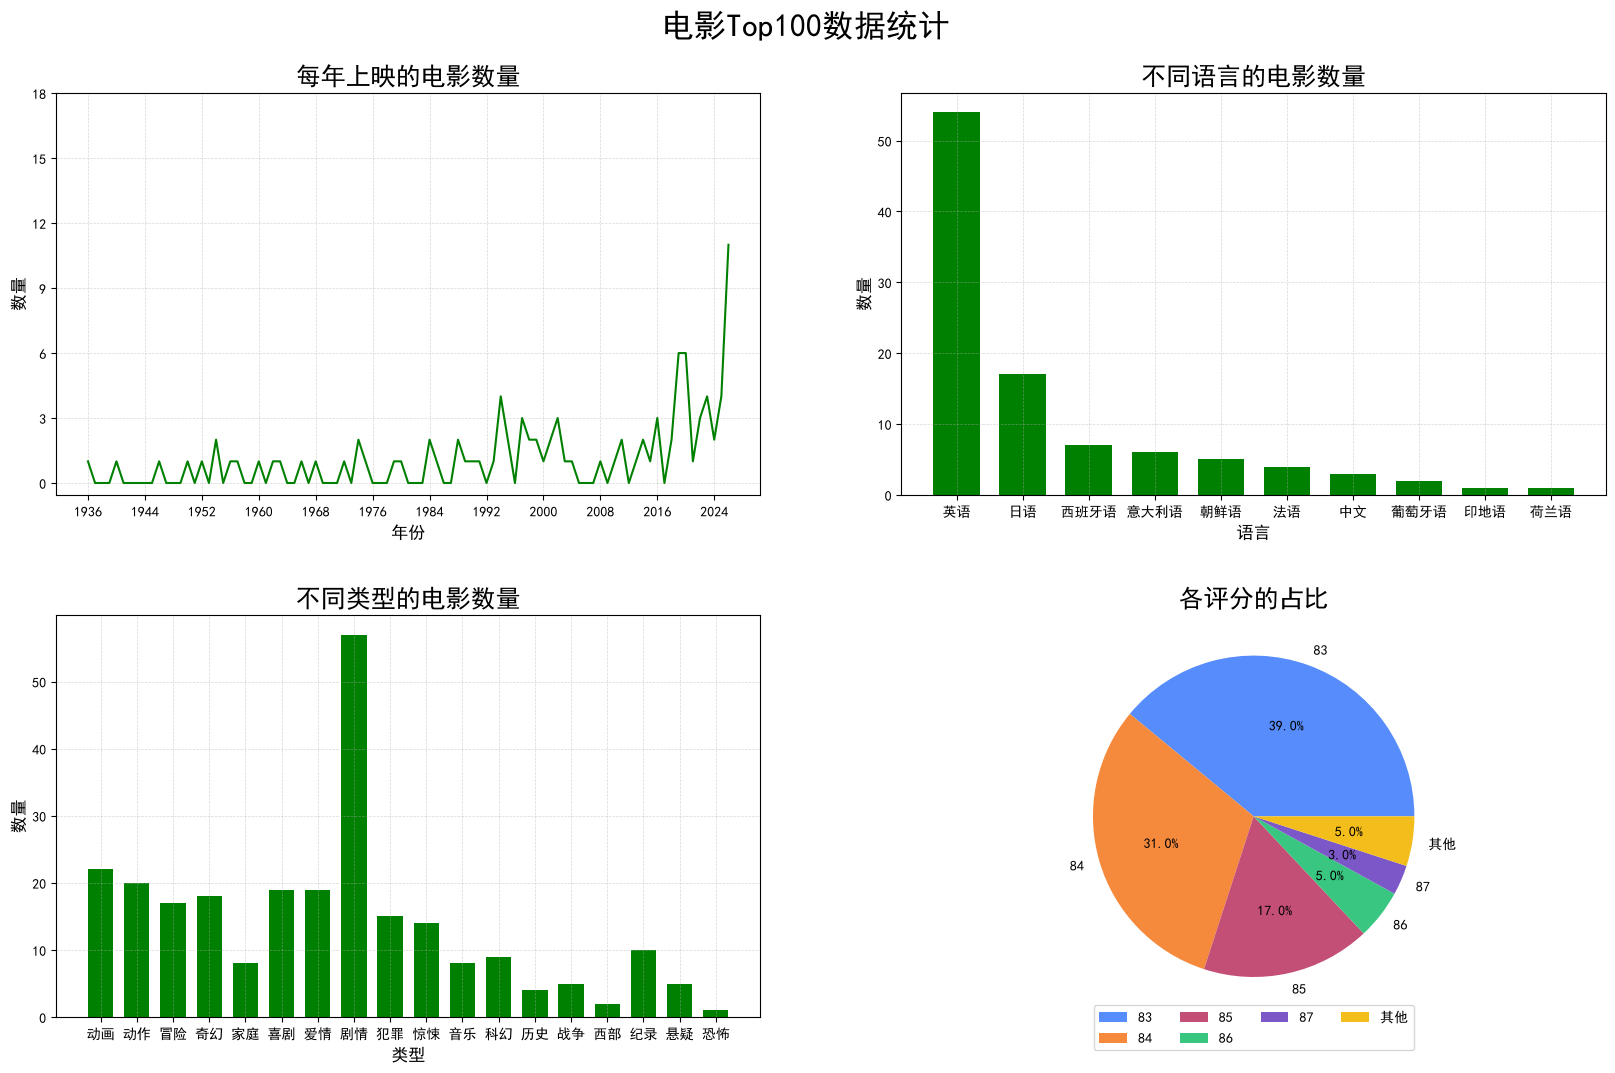

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

from pydantic import color
from pygments.lexers.sql import language_re

#展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

#从csv文件中获取数据
data = pd.read_csv('resourse/movie_top100.csv',usecols=['电影名','年份','上映时间','类型','时长','评分','语言'])

#设置子图
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 12))
#设置行间距与列间距
plt.subplots_adjust(wspace=0.2, hspace=0.3)

#设置全局标题
fig.suptitle('电影Top100数据统计', fontsize=23, x=0.5, y=0.95)
#获取四个子图
ax1 :Axes = ax[0, 0]
ax2 :Axes = ax[0, 1]
ax3 :Axes = ax[1, 0]
ax4 :Axes = ax[1, 1]

#统计每一年上映的电影
year=data.groupby('年份')['年份'].count()
#组装数据
year_max=year.index.max()
year_min=year.index.min()
#获取x轴的数据
x_year=[i for i in range(year_min,year_max+1)]
#获取y轴的数据
y_year=[int(year.get(i,0)) for i in x_year]
#绘制折线图
ax1.plot(x_year, y_year,color='g')
#设置标题
ax1.set_title('每年上映的电影数量', fontsize=18)
#设置x轴和y轴标签
ax1.set_xlabel('年份', fontsize=12)
ax1.set_ylabel('数量', fontsize=12)
#设置x轴和y轴刻度
ax1.set_xticks(x_year[::8])
ax1.set_yticks([i for i in range(0,20,3)])
#显示网格
ax1.grid(linestyle='--', alpha=0.5)


#统计不同语言的电影数量
#用中文替换'-'
language=data.replace('-', '中文').groupby('语言')['语言'].count().sort_values(ascending=False)
x_language=language.index.tolist()
y_language=language.values.tolist()
#柱状图的宽度由0.7
ax2.bar(x_language, y_language, color='g', width=0.7)

ax2.set_title('不同语言的电影数量', fontsize=18)
ax2.set_xlabel('语言', fontsize=12)
ax2.set_ylabel('数量', fontsize=12)
ax2.grid(linestyle='--', alpha=0.5)


#统计不同类型的电影
type_data={}
#这里遍历的是Series类型，其中的每一个元素是列表
for types in data['类型'].str.split(','):
    for type in types:
        if type in type_data:
            type_data[type] += 1
        else:
            type_data[type] = 1
#组装数据
x_type=list(type_data.keys())
y_type=list(type_data.values())
ax3.bar(x_type, y_type, color='g',width=0.7)

ax3.set_title('不同类型的电影数量', fontsize=18)
ax3.set_xlabel('类型', fontsize=12)
ax3.set_ylabel('数量', fontsize=12)
ax3.grid(linestyle='--', alpha=0.5)

#统计各评分的占比
rating=data.groupby('评分')['评分'].count()
#合并小数据（占比<=2%,合并成其他）
total=rating.sum()
#区分小数据与大数据:条件过滤
small_data=rating[rating/total<=0.02]
bag_data=rating[rating/total>0.02]
#将小数据合并成其他:shape返回行数
if small_data.shape[0]>0:
    bag_data['其他']=small_data.sum()
#组装数据
x_rating=bag_data.index.tolist()
y_rating=bag_data.values.tolist()
#绘制饼图, autopct设置标注格式，startangle设置起始角度
ax4.pie(y_rating, labels=x_rating, autopct='%1.1f%%', startangle=0)
ax4.set_title('各评分的占比', fontsize=18)
#设置标注  ,ncol设置列数,bbox_to_anchor设置标注位置
ax4.legend(loc='lower center',ncols=4,bbox_to_anchor=(0.5, -0.1))

#保存图表
plt.savefig('resourse/movie_top100.png')

#显示图表
plt.show()






